# What ``HoFa`` can do
This tutorial will acquaint you with the main functionalities of the ``HoFa`` package, which are the following:

1. Detect higher-order structure in signals.
2. Denoise signals with respect to higher-order structure.
3. Decompose signals into dominant higher-order components.

> **NOTE**: You will need the ``HoFa`` package installed before running this notebook, see the [Installation guide](../getting_started/installation). For a quick installation in a virtual environment (say, for example, ``hofavenv``), run the following command:

```console
(hofavenv) $ pip install hofa
```

# Detect higher-order structure: the ``norm`` module

The critical tools that we need for this section are the [Gowers norms](https://en.wikipedia.org/wiki/Gowers_norm), also known as **Gowers** $U^k$-**norms** or $U^k$-**norms** for short. These norms tell us whether there is some hidden quadratic (or higher-order) structure in a signal.

As an **example**, let us consider three different signals $f_1,f_2,f_3$ defined on $\{0,1,\ldots,n-1\}$:

$$ f_1(x) \sim \text{Unif}(-1,1) \text{ independently, } \quad f_2(x) = \sin(2\pi x/n), \quad f_3(x)=\sin(2\pi x^2/n).$$

In [1]:
import hofa.norm
import numpy as np

n = 501

# For reproducibility, we fix a Random Number Generator
rng = np.random.default_rng(123)

x = np.arange(n)

f_1 = rng.uniform(-1, 1, size=n)
f_2 = np.sin(2*np.pi*x/n)
f_3 = np.sin(2*np.pi*x**2/n)

Let us now plot the signals:

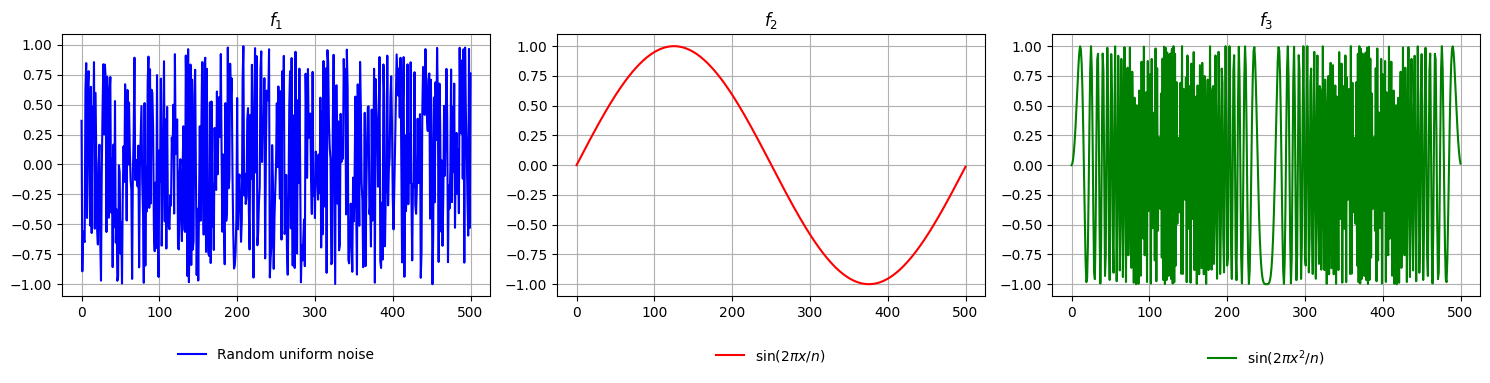

In [2]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Plot each function in its own subplot
ax1.plot(x, f_1, label='Random uniform noise', color='blue')
ax1.set_title(r'$f_1$')
ax1.grid(True)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)  # Display the legend for the first subplot

ax2.plot(x, f_2, label=r'$\sin(2\pi x/n)$', color='red')
ax2.set_title(r'$f_2$')
ax2.grid(True)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)  # Display the legend for the first subplot

ax3.plot(x, f_3, label=r'$\sin(2\pi x^2/n)$', color='green')
ax3.set_title(r'$f_3$')
ax3.grid(True)
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)  # Display the legend for the first subplot

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Clearly the three plots are different, but the first and third signals seem to have something in common: they both look like noise. Moreover, if we analyze such functions using the **Fourier transform**, we find that those two signals share the following interesting feature: **all** of their Fourier amplitudes are **small**, as we can see in the following plot.

> **NOTE**: We use the convention that, given a function $f:\{0,\ldots,n-1\}\to\mathbb{C}$ and a Fourier character $\chi$, the Fourier coefficient of $f$ at frequency $\chi$ is given by

$$ \widehat{f}(\chi)=\frac{1}{n}\sum_{x=0}^{n-1}f(x)\overline{\chi(x)}. $$


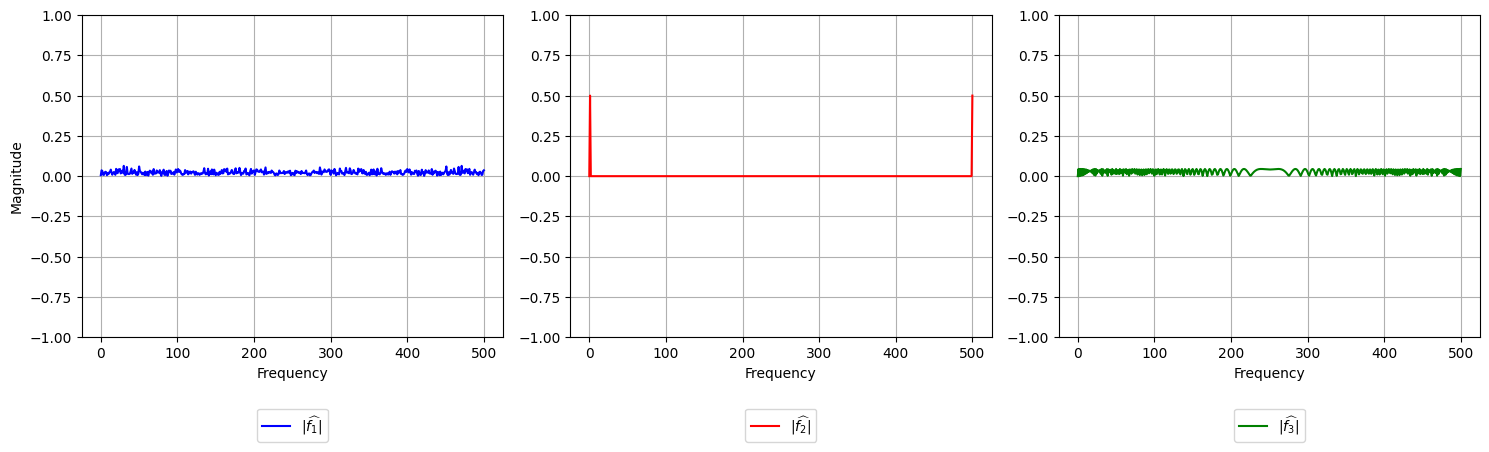

In [3]:
# Compute Fourier transforms
fft_1 = np.fft.fft(f_1, norm="forward")
fft_2 = np.fft.fft(f_2, norm="forward")
fft_3 = np.fft.fft(f_3, norm="forward")

# Create a figure with 3 subplots side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot absolute values of Fourier transforms
ax1.plot(x, np.abs(fft_1), label=r'$|\widehat{f_1}|$', color='blue')
ax1.set_xlabel('Frequency')
ax1.set_ylabel('Magnitude')
ax1.grid(True)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
ax1.set_ylim(-1, 1)

ax2.plot(x, np.abs(fft_2), label=r'$|\widehat{f_2}|$', color='red')
ax2.set_xlabel('Frequency')
ax2.grid(True)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
ax2.set_ylim(-1, 1)

ax3.plot(x, np.abs(fft_3), label=r'$|\widehat{f_3}|$', color='green')
ax3.set_xlabel('Frequency')
ax3.grid(True)
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
ax3.set_ylim(-1, 1)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Despite their similarity from the classical Fourier analytic viewpoint, the first and third signals are clearly *not* the same, the first signal is completely random noise whereas the third has quadratic behavior. Distinguishing this in a systematic way is precisely what the **Gowers norms** will enable. The Gowers norms are a family of norms defined on the space of functions $f:\{0,\ldots,N-1\}\to\mathbb{C}$ (or more general domains) that capture the following features:

- The Gowers $U^1$-seminorm captures the *average behavior*: how large is the average of a function; in particular, whether the function has a significant part that can be expressed as a constant. 
- The Gowers $U^2$-norm captures *linear behavior*: how sensitive is the function to (classical) Fourier-analytic methods; in particular, whether a significant part of it can be sparsely decomposed with functions of the form $\exp(2\pi i \xi x)$.
- The Gowers $U^3$-norm captures *quadratic behavior*: in particular, whether a function has a significant part that can be sparsely decomposed with *quadratic harmonics* such as $\exp(2\pi i (\xi x^2+\xi'x))$.
- The Gowers $U^4$-norm...

> **NOTE**: The Gowers $U^1$-seminorm can be seen to fit into the scheme of the higher-order norms, in that it detects whether a function has a significant part that can be expressed as a multiple of $\exp(2\pi i \xi x^0)$, i.e. of a constant function. It is a common abuse of notation to talk about the Gowers $U^k$-norms collectively even though the case $k=1$ is only a *semi*norm (it is also common to refer to the $U^1$-seminorm simply as the $U^1$-norm).

The formal definition of the Gowers norms is provided in this documentation in the [conceptual and mathematical background of higher-order Fourier analysis](concept-background).

> **Observation**: The Gowers $U^k$-norms ($k\ge 1$) form an *increasing* sequence of norms. That is, for a functon $f$, if we let $\|f\|_{U^k}$ denote its $U^k$-norm, then $\|f\|_{U^1}\le \|f\|_{U^2}\le \|f\|_{U^3}\le\cdots$. This aligns with the picture described before; e.g. having some non-trivial linear (classical Fourier) structure implies having quadratic structure, as functions of the form $\exp(2\pi i (\xi x^2+\xi'x))$ already include the linear cases $\exp(2\pi i \xi'x)$ (just by setting $\xi=0$).

The ``HoFa`` package can be used to compute the Gowers norms; let us compute them for the examples $f_1,f_2,f_3$ above:

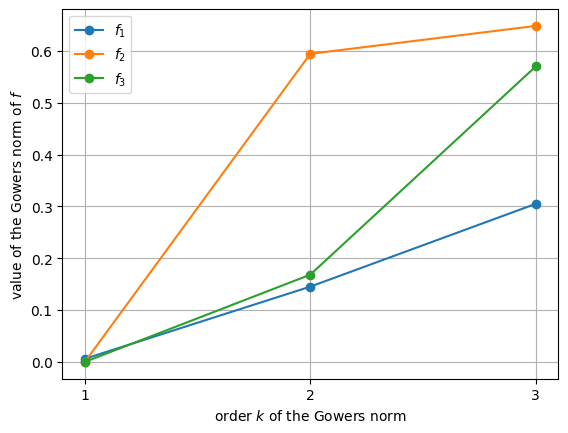

In [4]:
norm_axis = np.arange(1,4)

# Compute y-values for each array
y1 = [hofa.norm.u(f_1, i) for i in norm_axis]
y2 = [hofa.norm.u(f_2, i) for i in norm_axis]
y3 = [hofa.norm.u(f_3, i) for i in norm_axis]

# Plot
plt.plot(norm_axis, y1, marker='o', label=r'$f_1$')
plt.plot(norm_axis, y2, marker='o', label=r'$f_2$')
plt.plot(norm_axis, y3, marker='o', label=r'$f_3$')

# Labels and legend
plt.xlabel('order $k$ of the Gowers norm')
plt.ylabel(r'value of the Gowers norm of $f$')
plt.xticks(norm_axis)
plt.legend()
plt.grid(True)

plt.show()

Note the significant differences between the $U^2$-norms and $U^3$-norms of these functions. In general, if a function has a $U^k$-norm that is non-trivially large (and thus markedly different from the $U^k$-norm of random $[-1,1]$-valued noise), then this signals the presence of some kind of *structure* of order $k-1$ in the function. Let us analyze the above example in this light:

- As $\|f_2\|_{U^2}$ is significantly larger than $\|f_1\|_{U^2}$, this signals the presence of **linear (classical Fourier) structure** in $f_2$.
- As $\|f_3\|_{U^2}$ is similar to $\|f_1\|_{U^2}$, this signals that, **relative to (classical) Fourier analysis, the signals are similar**.
- As $\|f_3\|_{U^3}$ is significantly larger than $\|f_1\|_{U^3}$, this signals the presence of **quadratic structure** in $f_3$.

# Denoise signals with respect to higher-order structure

Usually, signals in real scenarios do not come in such neatly distinct ways as in the previous example. Instead, what we commonly encounter is a superposition of the structured signal with some added noise. Continuing with the examples $f_1(x)\sim\text{Unif}(-1,1)$ and $f_3(x)=\sin(2\pi x^2/n)$, imagine that we are trying to send the signal $f_3$ but the channel which we use introduces a $t=50\%$ noise (represented by the function $f_1$). Then, at the receptor we receive 

$$g=(1-t)f_3+tf_1.$$

In [5]:
t = 0.5

g = (1-t)*f_3+t*f_1

The ``HoFa`` package includes a **Regularization method** that helps to recover the quadratically structured component $(1-t)f_2$. **Note** that Fourier based methods are of little use for this, as the Fourier transforms of $f_1$ and $f_3$ are very small and the Fourier transform of the perturbed version $g$ need not be similar to the Fourier transform of $f_3$.

The method that enables the mentioned recovery is ``hofa.rgz.regularize``:

In [6]:
import hofa.rgz

regularized_g = np.real(hofa.rgz.regularize(g,2).regularization)

Let us now plot the results:

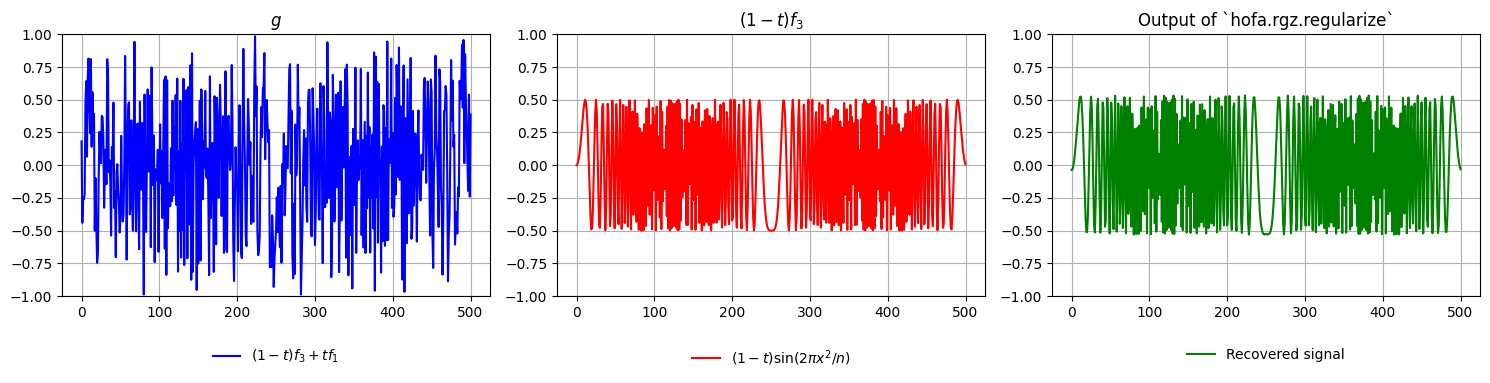

L^1 difference between (1-t)f_3 and the output: 0.0016458352513586331


In [7]:
# Create a figure with 3 subplots side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Plot each function in its own subplot
ax1.plot(x, g, label=r'$(1-t)f_3+tf_1$', color='blue')
ax1.set_title(r'$g$')
ax1.grid(True)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)  # Display the legend for the first subplot
ax1.set_ylim(-1, 1)

ax2.plot(x, (1-t)*f_3, label=r'$(1-t)\sin(2\pi x^2/n)$', color='red')
ax2.set_title(r'$(1-t)f_3$')
ax2.grid(True)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)  # Display the legend for the first subplot
ax2.set_ylim(-1, 1)

ax3.plot(x, regularized_g, label=r'Recovered signal', color='green')
ax3.set_title(r'Output of `hofa.rgz.regularize`')
ax3.grid(True)
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)  # Display the legend for the first subplot
ax3.set_ylim(-1, 1)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

print(f'L^1 difference between (1-t)f_3 and the output: {np.abs(np.mean(regularized_g-(1-t)*f_3))}')

# Decompose signals into their higher-order components

Finally, ``HoFa`` enables us to decompose functions into their higher-order components. Imagine that we are now sending three chirps $h_1,h_2,h_3:\{0,\ldots,M-1\}\to \mathbb{C}$, for $M=1001$, defined as follows:

$$ h_1(x) = \exp(2\pi i x^2/M), \quad h_2(x) = \exp(10\pi i x^2/M), \quad h_3(x) = \exp(14\pi i x^2/M),$$

but our receptor has received at onces the three chirps superposed, i.e. we receive $w=(h_1+h_2+h_3)/3$.

In [8]:
M = 1001
x = np.arange(M)

h_1 = np.exp(2*np.pi*1j*x**2/M)
h_2 = np.exp(10*np.pi*1j*x**2/M)
h_3 = np.exp(14*np.pi*1j*x**2/M)

w = (h_1+h_2+h_3)/3

The ``HoFa`` package includes a **Spectral higher-order Fourier transform** implemented in ``hofa.char.spechoft`` that can identify and separate the different quadratic components of this example.

In [9]:
import hofa.char

# As usual, we fix a Random Number Generator for reproducibility
rnd_sep_result = hofa.char.spechoft(w, order = 2, rng=28) 

eichars = rnd_sep_result.higher_order_char

Let us plot the result of this function against the known underlying functions $h_1,h_2,h_3$. Note that ``hofa.char.spechoft`` does not return the different components in a particular order. Thus, we have to find the most appropriate order for better visualization.

In [10]:
import itertools

# For convenience, we only plot the first 500 elements of each function
number_of_first_elems_to_plot = 500

v_1 = eichars[:, -1]
coeff_proj_1 = np.mean(w * v_1.conjugate())

v_2 = eichars[:, -2]
coeff_proj_2 = np.mean(w * v_2.conjugate())

v_3 = eichars[:, -3]
coeff_proj_3 = np.mean(w * v_3.conjugate())

# Restrict to plotting window
x_plot = x[:number_of_first_elems_to_plot]

# Target ("green") complex curves
target_1_complex = h_1 / 3
target_2_complex = h_2 / 3
target_3_complex = h_3 / 3

targets_complex = [target_1_complex, target_2_complex, target_3_complex]

# Recovered ("blue") complex curves
blue_1_complex = coeff_proj_1 * v_1#[:number_of_first_elems_to_plot]
blue_2_complex = coeff_proj_2 * v_2#[:number_of_first_elems_to_plot]
blue_3_complex = coeff_proj_3 * v_3#[:number_of_first_elems_to_plot]

blues_complex = [blue_1_complex, blue_2_complex, blue_3_complex]

# --- L^2 (squared) error comparison over all 3! possible assignments ---
# Match using the full complex-valued curves

best_perm = None
best_err = np.inf

for perm in itertools.permutations(range(3)):
    total_err = sum(
        np.sum(np.abs(blues_complex[perm[i]] - targets_complex[i])**2)
        for i in range(3)
    )
    if total_err < best_err:
        best_err = total_err
        best_perm = perm

# Reorder blues according to best assignment
matched_blues_complex = [blues_complex[best_perm[i]] for i in range(3)]

# Labels
target_labels_real = [
    r'$\mathrm{Re}\!\left(\exp(2\pi i x^2/n)/3\right)$',
    r'$\mathrm{Re}\!\left(\exp(10\pi ix^2/n)/3\right)$',
    r'$\mathrm{Re}\!\left(\exp(14\pi ix^2/n)/3\right)$',
]

target_labels_imag = [
    r'$\mathrm{Im}\!\left(\exp(2\pi i x^2/n)/3\right)$',
    r'$\mathrm{Im}\!\left(\exp(10\pi ix^2/n)/3\right)$',
    r'$\mathrm{Im}\!\left(\exp(14\pi ix^2/n)/3\right)$',
]

blue_labels_real = [
    r"real part of matched quadratic character 1",
    r"real part of matched quadratic character 2",
    r"real part of matched quadratic character 3",
]

blue_labels_imag = [
    r"imaginary part of matched quadratic character 1",
    r"imaginary part of matched quadratic character 2",
    r"imaginary part of matched quadratic character 3",
]

Finally, we can plot the results once we have the best matching between the components found by ``hofa.char.spechoft`` and the original functions $h_1,h_2,h_3$.

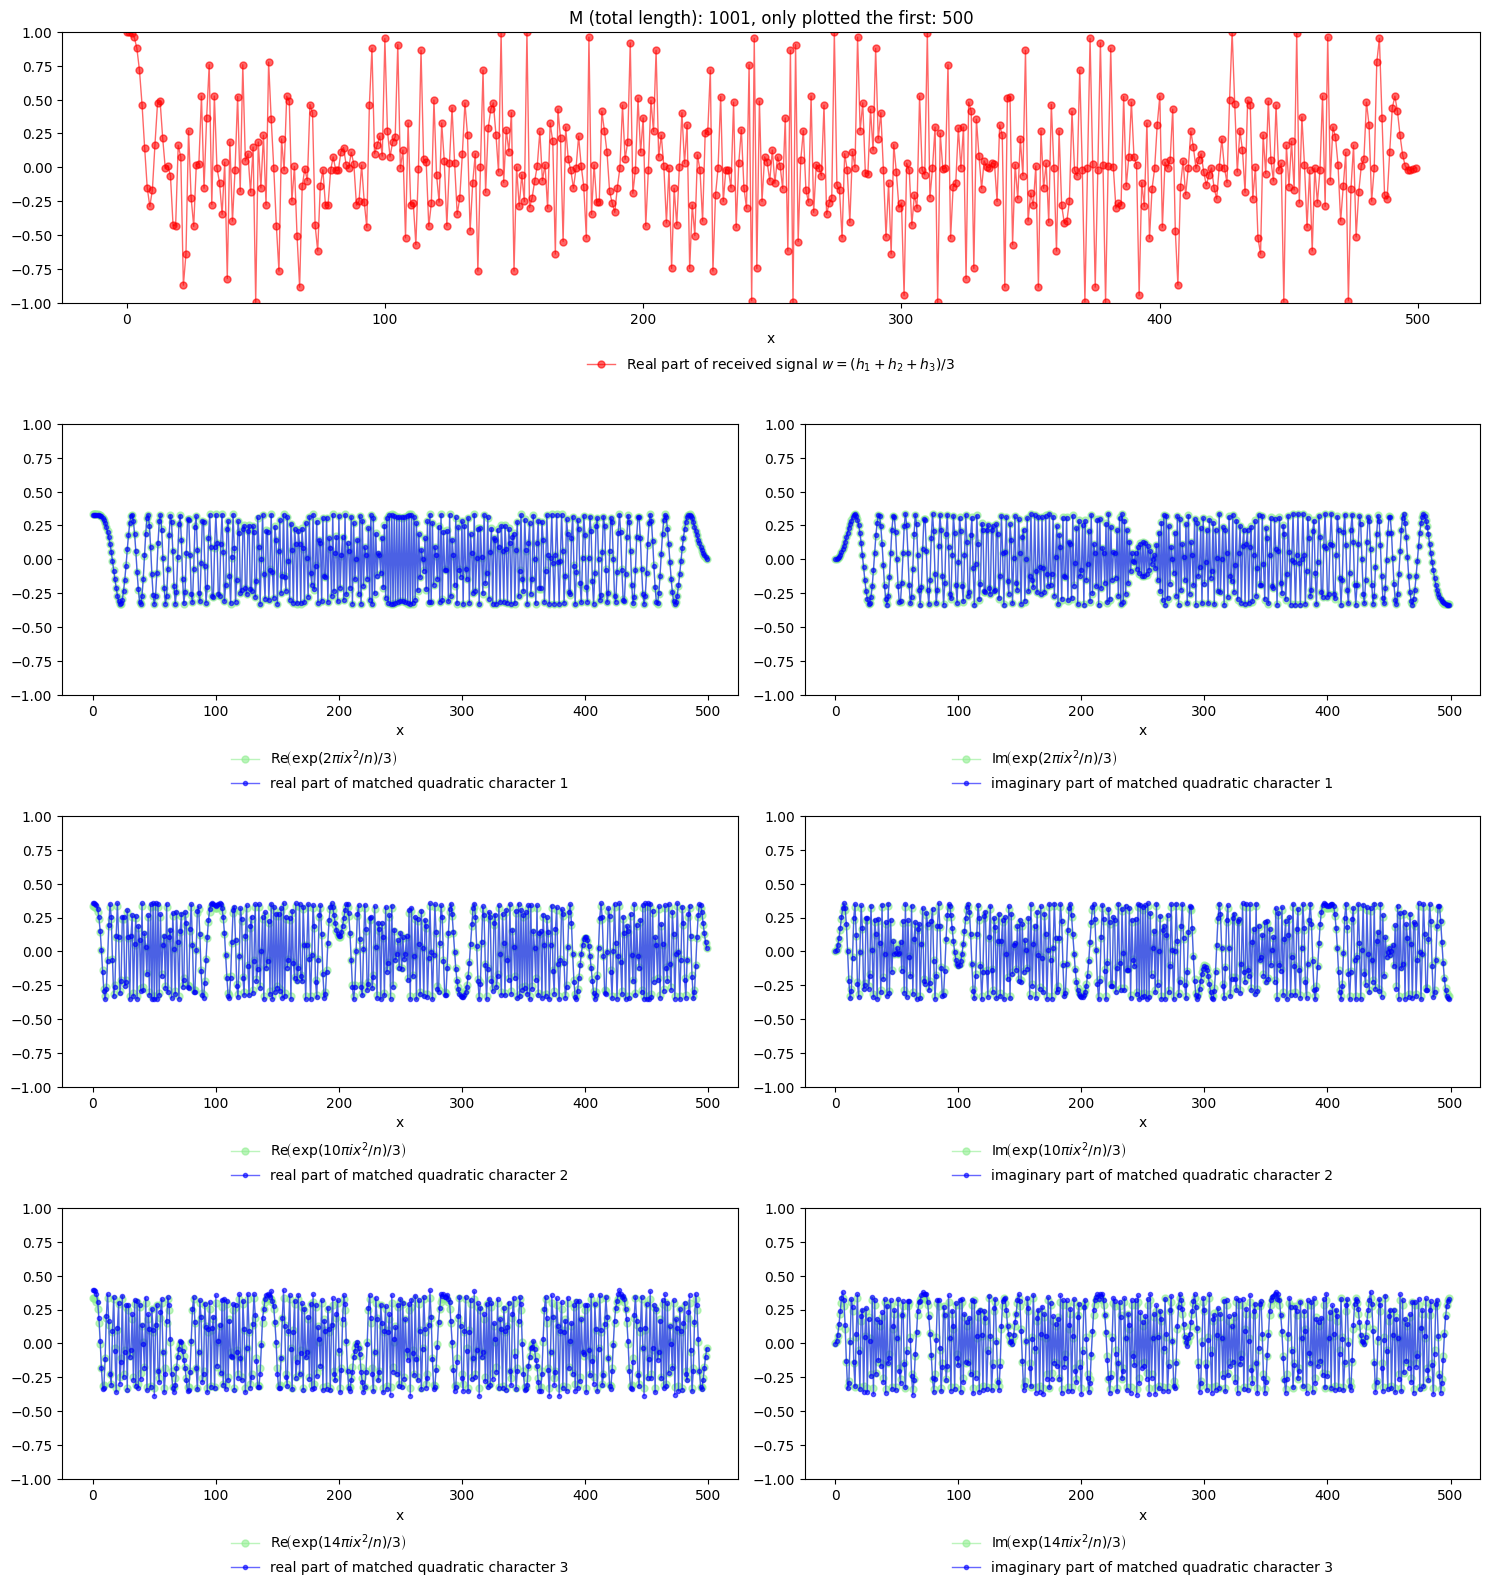

In [11]:

# --- Plotting ---

# 4 rows x 2 columns:
# top row spans both columns,
# then 3 rows of 2 plots each
fig = plt.figure(figsize=(15, 16))
gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1, 1], width_ratios=[1, 1])

# Top plot
ax_top = fig.add_subplot(gs[0, :])
ax_top.plot(
    x_plot,
    np.real(w[:number_of_first_elems_to_plot]),
    linestyle="-",
    color="red",
    marker="o",
    markersize=5,
    linewidth=1,
    alpha=0.6,
    label=r"Real part of received signal $w=(h_1+h_2+h_3)/3$",
)
ax_top.set_xlabel("x")
ax_top.set_title(f"M (total length): {M}, only plotted the first: {number_of_first_elems_to_plot}")
ax_top.set_ylim(-1, 1)
ax_top.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Bottom 3x2 comparison plots
for i in range(3):
    target = targets_complex[i]
    blue = matched_blues_complex[i]

    # Left: real parts
    ax_real = fig.add_subplot(gs[i + 1, 0])
    ax_real.plot(
        x_plot,
        np.real(target[:number_of_first_elems_to_plot]),
        linestyle="-",
        color="lightgreen",
        marker="o",
        markersize=5,
        linewidth=1,
        alpha=0.6,
        label=target_labels_real[i],
    )
    ax_real.plot(
        x_plot,
        np.real(blue[:number_of_first_elems_to_plot]),
        linestyle="-",
        color="blue",
        marker="o",
        markersize=3,
        linewidth=1,
        alpha=0.6,
        label=blue_labels_real[i],
    )
    ax_real.set_xlabel("x")
    ax_real.set_ylim(-1, 1)
    ax_real.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False)

    # Right: imaginary parts
    ax_imag = fig.add_subplot(gs[i + 1, 1])
    ax_imag.plot(
        x_plot,
        np.imag(target[:number_of_first_elems_to_plot]),
        linestyle="-",
        color="lightgreen",
        marker="o",
        markersize=5,
        linewidth=1,
        alpha=0.6,
        label=target_labels_imag[i],
    )
    ax_imag.plot(
        x_plot,
        np.imag(blue[:number_of_first_elems_to_plot]),
        linestyle="-",
        color="blue",
        marker="o",
        markersize=3,
        linewidth=1,
        alpha=0.6,
        label=blue_labels_imag[i],
    )
    ax_imag.set_xlabel("x")
    ax_imag.set_ylim(-1, 1)
    ax_imag.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False)

fig.tight_layout()
plt.show()